In [1]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 1.0, 'Entropía: 0.721763067193911')

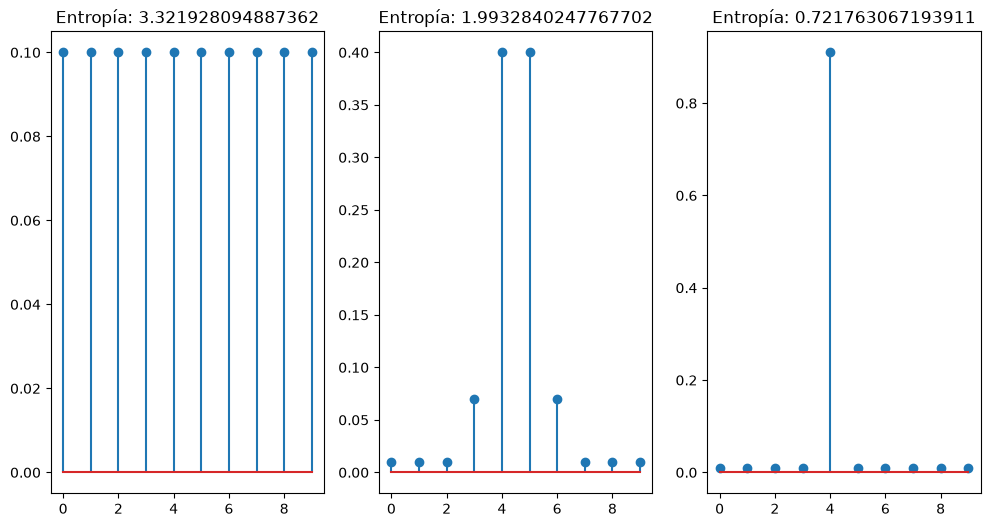

In [7]:
def H(x):
  x=np.array(x) #Garantizando que el arreglo es numérico
  x=np.where(x==0,1e-20,x) #Garantizando que no hay ceros en el vector
  x=x/np.sum(x) #Garantizando que el vector está normalizado y corresponde a probabilidades
  return -np.sum(x*np.log2(x))

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
pr=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))

plt.subplot(1,3,2)
pr=[0.01, 0.01, 0.01, 0.07, 0.4, 0.4, 0.07, 0.01, 0.01, 0.01]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))

plt.subplot(1,3,3)
pr=[0.01, 0.01, 0.01, 0.01, 0.91, 0.01, 0.01, 0.01, 0.01, 0.01]
plt.stem(pr)
plt.title('Entropía: '+str(H(pr)))


Bits necesarios para transmitir 11 símbolos equiprobables: 4.0 bits
Pero la entropía de esta fuente es: 3.4594316186372973 bits
Si se transmiten en grupos de 11 símbolos originales, ahora hay 45949729863572161 símbolos equiprobables, y se necesitan 56.0 bits para transmitirlos
Pero como en cada símbolo nuevo, hay 16 símbolos originales, la entropía por símbolo original es: 3.5 bits


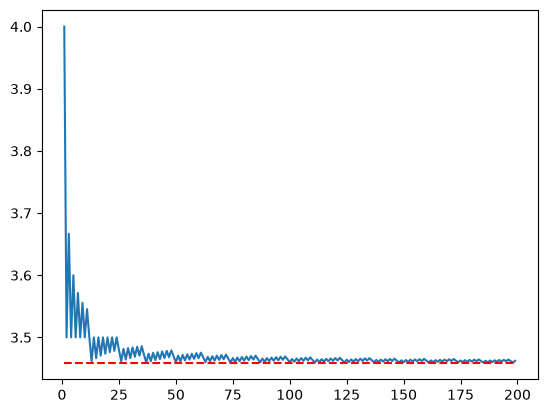

In [66]:
#Si tuviéramos que transmitir L símbolos equiprobables, con codificación binaria normal, necesitaríamos
L=11
print(f'Bits necesarios para transmitir {L} símbolos equiprobables: {np.ceil(np.log2(L))} bits')
print(f'Pero la entropía de esta fuente es: {np.log2(L)} bits')

#Dónde está la diferencia? Si yo agrupo los símbolos y los transmito de a k símbolos juntos, aparecen ahora
k=16
print(f'Si se transmiten en grupos de {L} símbolos originales, ahora hay {L**k} símbolos equiprobables, y se necesitan {np.ceil(k*np.log2(L))} bits para transmitirlos')
print(f'Pero como en cada símbolo nuevo, hay {k} símbolos originales, la entropía por símbolo original es: {np.ceil(k*np.log2(L))/k} bits')
ki=[]
hi=[]

for k in range(1,200):
    ki.append(k)
    hi.append(np.ceil(k*np.log2(L))/k)
plt.plot(ki,hi)
plt.hlines(xmin=1, xmax=max(ki), y=np.log2(L), color='r', linestyle='--')

In [ ]:
!wget -q 'https://www.robertohincapie.com/data/libro_muertos.txt'
with open('libro_muertos.txt', encoding='latin1') as file:
  lines = file.readlines()

In [ ]:
#Un ejemplo bien interesante. La entropía de palabras y de letras de un documento
cad=''
caracteres='abcdefghijklmnñopqrstuvwxyzáéíóú'
for li in lines:
  cad=cad+' '+li.lower()
contador={}
for ch in cad:
  if(ch in caracteres):
    if(ch not in contador.keys()):
      contador[ch]=1
    else:
      contador[ch]+=1
print(contador)
n=list(contador.values())
pr=np.array(n)/np.sum(n)

print('Entropía de las letras = ',H(pr))

#Si todas las letras fueran equiprobables,
n=np.ones(len(pr))
pr=np.array(n)/np.sum(n)
print('Entropía de las letras (si fueran equiprobables) = ',H(pr))

#entropia de las vocales
n=[contador['a'], contador['e'], contador['i'], contador['o'], contador['u']]
pr=np.array(n)/np.sum(n)

print('Entropía de las vocales: ',-np.sum(pr*np.log2(pr)))

{'e': 5279, 'l': 2302, 'i': 2180, 'b': 301, 'r': 2264, 'o': 3139, 'd': 1725, 's': 2954, 'm': 1244, 'u': 1458, 't': 1713, 'a': 3701, 'n': 2650, 'w': 5, 'c': 1661, 'q': 279, 'z': 85, 'p': 833, 'g': 331, 'í': 237, 'h': 248, 'y': 297, 'ó': 240, 'v': 427, 'á': 147, 'k': 12, 'f': 282, 'j': 93, 'ú': 38, 'x': 61, 'é': 67, 'ñ': 43}
Entropía de las letras =  4.098814720971937
Entropía de las letras (si fueran equiprobables) =  5.0
Entropía de las vocales:  2.1956875347796125


In [ ]:
#Calcular la entropía de las palabras
cadena = ''

for linea in lines:
    cadena = cadena +' '+ linea.lower()
#Para quitar los caracteres no alfanuméricos
permited='0123456789áéíóúñabcdefghijklmnopqrstuvwxyz '
cadena = ''.join([e for e in cadena.lower() if e in permited])

palabras = cadena.split()
contador_palabras = {}
for palabra in palabras:
  if (palabra not in contador_palabras.keys()):
    contador_palabras[palabra] = 1
  else:
    contador_palabras[palabra] += 1
print(contador_palabras)
n_p = list(contador_palabras.values())
pr=np.array(n_p)/np.sum(n_p)
print("Entropía de las palabras =",H(pr))
print('Num palabras: ',len(contador_palabras))
print("Entropía de las palabras (si fueran equiprobables) = ",np.log2(len(contador_palabras)))


{'el': 321, 'libro': 11, 'de': 396, 'los': 163, 'muertos': 7, 'samael': 4, 'aun': 4, 'weor': 4, 'instituto': 2, 'cultural': 2, 'quetzalcoatl': 2, 'antropología': 2, 'psicoanalítica': 2, 'ac': 2, 'httpsamaelgnosisnet': 2, 'y': 200, 'httpsamaelgnosisorg': 2, 'índice': 1, 'prologo': 2, 'del': 104, 'editor': 2, 'introducción': 2, 'capítulo': 8, 'i': 2, 'la': 407, 'muerte': 58, 'rayo': 7, 'lo': 35, 'que': 182, 'continua': 2, 'cuerpo': 82, 'vital': 27, 'quinta': 9, 'dimensión': 17, 'ii': 2, 'ángeles': 19, 'iii': 2, 'tribunales': 4, 'karma': 7, 'iv': 2, 'cuatro': 6, 'círculos': 4, 'avitchi': 13, 'reino': 8, 'mineral': 10, 'región': 17, 'celular': 14, 'molecular': 31, 'mundo': 54, 'electrónico': 22, 'mucho': 6, 'se': 92, 'ha': 9, 'hablado': 1, 'mayoría': 1, 'las': 68, 'gentes': 8, 'creen': 5, 'aseguran': 3, 'nadie': 6, 'sabe': 1, 'nada': 3, 'al': 40, 'respecto': 1, 'pero': 17, 'nosotros': 9, 'gnósticos': 1, 'afirmamos': 1, 'con': 70, 'conocimiento': 5, 'objetivo': 3, 'es': 141, 'paso': 1, 'un'

In [ ]:
#Primeras letras
inicio=[pal[0] for pal in palabras]
inicio=list(set(inicio))
#print(inicio)

def entropia_de_palabras(palabras2):
  contador_palabras = {}
  for palabra in palabras2:
    if (palabra not in contador_palabras.keys()):
        contador_palabras[palabra] = 1
    else:
        contador_palabras[palabra] += 1
  n=list(contador_palabras.values())
  pr=np.array(n)/np.sum(n)
  return -np.sum(pr*np.log2(pr))

H=0 #Entropia condicional
for letra in inicio:
  palabras2=[pal for pal in palabras if pal[0]==letra]
  hc=entropia_de_palabras(palabras2)
  pr=len(palabras2)/len(palabras)
  #print('Letra:',letra,', Probabilidad de la letra:', pr, ', Entropía de la palabras que comienzan con esa letra:', hc)
  H=H+pr*hc
print('La entropía condicional es: ',H)

La entropía condicional es:  4.533633745918426


In [ ]:
#Primeras letras
#Palabras que miden al menos 2 caracteres
palabras3=[pal for pal in palabras if len(pal)>=2]
inicio=[pal[0:2] for pal in palabras3]
inicio=list(set(inicio))
#print(inicio)

def entropia_de_palabras(palabras2):
  contador_palabras = {}
  for palabra in palabras2:
    if (palabra not in contador_palabras.keys()):
        contador_palabras[palabra] = 1
    else:
        contador_palabras[palabra] += 1
  n=list(contador_palabras.values())
  pr=np.array(n)/np.sum(n)
  return -np.sum(pr*np.log2(pr))

H=0 #Entropia condicional
for letras in inicio:
  palabras2=[pal for pal in palabras3 if pal[0:2]==letras]
  hc=entropia_de_palabras(palabras2)
  pr=len(palabras2)/len(palabras3)
  #print('Letras:',letras,', Probabilidad de la letra:', pr, ', Entropía de la palabras que comienzan con esa letra:', hc)
  H=H+pr*hc
print('La entropía condicional es: ',H)
inicio=list(set(inicio))
#print(inicio)

La entropía condicional es:  2.710987807793033


In [ ]:
!wget -q 'https://www.robertohincapie.com/data/permanencia_ingenierias.csv'
import pandas as pd
data=pd.read_csv('permanencia_ingenierias.csv', sep=';', encoding='latin1', decimal=',')
#data=pd.read_csv('permanencia_ingenierias.csv', sep=';', encoding='latin1',decimal = ",")
data.head()

,Edad,SEXO,ALERTASROJAS,ALERTASNARANJAS,ALERTASACADEMICAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,CRÉDITOS CANCELADOS,CREDITOS INTENTADOS,PROMEDIO GLOBAL,ULTIMO ESTADO ACADÉMICO,APOYOS ECONÓMICO EN MATRICULA,APOYO INSTITUCIONAL,DESERSIÓN
0,21,M,14,17,0,0,10.31,28.21,22.37,10.61,3,65,0,68,3.832059,Estado académico normal,SI,SI,NO
1,21,F,14,15,0,0,5.15,28.21,22.37,15.15,15,84,9,108,3.614646,Estado académico normal,SI,SI,NO
2,19,F,13,19,0,0,8.25,28.21,21.05,15.15,6,8,3,17,2.855000,Advertencia académica,SI,SI,SI
3,20,F,12,18,0,0,9.28,35.90,15.79,10.61,3,44,3,50,3.808936,Estado académico normal,SI,NO,NO
4,20,F,12,14,0,0,10.31,17.95,23.68,4.55,0,149,4,153,4.202685,Estado académico normal,SI,SI,NO


In [ ]:
pr=data['DESERSIÓN'].value_counts().values
print(pr)
def H(x):
  x=np.array(x) #Garantizando que el arreglo es numérico
  x=x/np.sum(x) #Garantizando que el vector está normalizado y corresponde a probabilidades
  return -np.sum(x*np.log2(x))

Entropia_Desersion=H(pr)
print('Entropia de la desersión es: ',Entropia_Desersion)

[800 114]
Entropia de la desersión es:  0.5427960734010016


In [ ]:
data[['ULTIMO ESTADO ACADÉMICO','DESERSIÓN']].value_counts()

ULTIMO ESTADO ACADÉMICO       DESERSIÓN
Estado académico normal       NO           693
Advertencia académica         NO            86
Estado académico normal       SI            46
Advertencia académica         SI            44
Suspensión académica          SI            19
Primer reingreso              NO            11
Suspensión académica          NO             5
Segunda suspensión académica  NO             3
                              SI             3
Primer reingreso              SI             2
Segundo reingreso             NO             2
dtype: int64

In [ ]:
data.head()

,Edad,SEXO,ALERTASROJAS,ALERTASNARANJAS,ALERTASACADEMICAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,CRÉDITOS CANCELADOS,CREDITOS INTENTADOS,PROMEDIO GLOBAL,ULTIMO ESTADO ACADÉMICO,APOYOS ECONÓMICO EN MATRICULA,APOYO INSTITUCIONAL,DESERSIÓN
0,21,M,14,17,0,0,10.31,28.21,22.37,10.61,3,65,0,68,3.832059,Estado académico normal,SI,SI,NO
1,21,F,14,15,0,0,5.15,28.21,22.37,15.15,15,84,9,108,3.614646,Estado académico normal,SI,SI,NO
2,19,F,13,19,0,0,8.25,28.21,21.05,15.15,6,8,3,17,2.855000,Advertencia académica,SI,SI,SI
3,20,F,12,18,0,0,9.28,35.90,15.79,10.61,3,44,3,50,3.808936,Estado académico normal,SI,NO,NO
4,20,F,12,14,0,0,10.31,17.95,23.68,4.55,0,149,4,153,4.202685,Estado académico normal,SI,SI,NO


[Text(0.5, 0.875, 'PROMEDIO GLOBAL <= 3.118\ngini = 0.218\nsamples = 914\nvalue = [800, 114]\nclass = NO'),
 Text(0.25, 0.625, 'ULTIMO ESTADO ACADÉMICO_Suspensión académica <= 0.5\ngini = 0.5\nsamples = 128\nvalue = [63, 65]\nclass = SI'),
 Text(0.125, 0.375, 'CREDITOS INTENTADOS <= 27.5\ngini = 0.491\nsamples = 106\nvalue = [60, 46]\nclass = NO'),
 Text(0.0625, 0.125, 'gini = 0.488\nsamples = 59\nvalue = [25, 34]\nclass = SI'),
 Text(0.1875, 0.125, 'gini = 0.38\nsamples = 47\nvalue = [35, 12]\nclass = NO'),
 Text(0.375, 0.375, 'CAL.FAMILIAR <= 32.055\ngini = 0.236\nsamples = 22\nvalue = [3, 19]\nclass = SI'),
 Text(0.3125, 0.125, 'gini = 0.172\nsamples = 21\nvalue = [2, 19]\nclass = SI'),
 Text(0.4375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = NO'),
 Text(0.75, 0.625, 'CRÉDITOS APROBADOS <= 13.5\ngini = 0.117\nsamples = 786\nvalue = [737, 49]\nclass = NO'),
 Text(0.625, 0.375, 'CRÉDITOS CANCELADOS <= 7.0\ngini = 0.315\nsamples = 92\nvalue = [74, 18]\nclass = NO'),
 Text

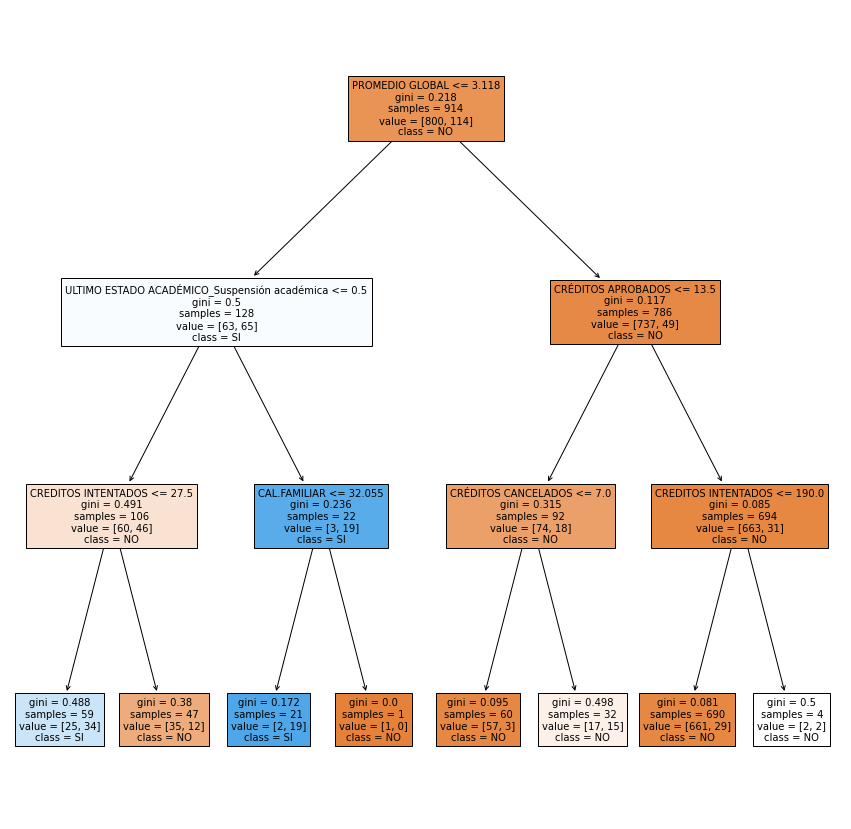

In [ ]:
from sklearn import tree
model_Tree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=1, max_depth=3)

data['DESERSIÓN']=data['DESERSIÓN'].replace({'NO':0, 'SI':1})
data2=data.copy()
data = pd.get_dummies(data, columns=['ULTIMO ESTADO ACADÉMICO'], drop_first=True)
data['APOYOS ECONÓMICO EN MATRICULA']=data['APOYOS ECONÓMICO EN MATRICULA'].replace({'NO':0, 'SI':1})
data['SEXO']=data['SEXO'].replace({'M':0, 'F':1,'N':2})
data['APOYO INSTITUCIONAL']=data['APOYO INSTITUCIONAL'].replace({'NO':0, 'SI':1})
Y = data["DESERSIÓN"]
X = data.drop(["DESERSIÓN"],axis=1)
model_Tree.fit(X,Y)

from sklearn.tree import plot_tree

nombres_variables=X.columns.values

plt.figure(figsize=(15,15))
plot_tree(model_Tree, feature_names=nombres_variables, class_names=['NO','SI'], filled=True,fontsize=10)

In [ ]:
#Mirar el concepto de entropía condicional
def entropia(x): #supongo que x es un arreglo
  x=np.array(x)
  x=x/x.sum()
  return -np.sum(x*np.log2(x))

def entropia_condicional(data,y,x): #La entropía de la variable y condicionada a la variable x
  H=0
  n=len(data)
  est=list(data[x].unique())
  for es in est:
    data2=data[data[x]==es]
    pr=len(data2)/n
    num=data2[y].value_counts().values
    H=H+pr*entropia(num)
  return H

def entropia_condicional_discretizando(data,y,x, n=20): #La entropía de la variable y condicionada a la variable x. La variable x debe discretizarse
  data2=data[[x,y]]
  xi=data2[x].values
  mi=np.min(xi)
  ma=np.max(xi)
  dx=(ma-mi)/n
  xi=np.floor((xi-mi)/dx)
  data2[x]=xi
  return entropia_condicional(data2, y,x)

In [ ]:
H=entropia(data2['DESERSIÓN'].value_counts().values)
print('Entropia de la desersión: ', H)
print('Entropia de la desersión respecto al ultimo estado academico: ', entropia_condicional(data2, 'DESERSIÓN', 'ULTIMO ESTADO ACADÉMICO'), 'Ganancia: ',H-entropia_condicional(data2, 'DESERSIÓN', 'ULTIMO ESTADO ACADÉMICO'))
print('Entropia de la desersión respecto al SEXO: ', entropia_condicional(data2, 'DESERSIÓN', 'SEXO'), 'Ganancia: ',H-entropia_condicional(data2, 'DESERSIÓN', 'SEXO'))
print('Entropia de la desersión respecto al Promedio global: ', entropia_condicional_discretizando(data2, 'DESERSIÓN', 'PROMEDIO GLOBAL'), 'Ganancia: ',H-entropia_condicional_discretizando(data2, 'DESERSIÓN', 'PROMEDIO GLOBAL'))
print('Entropia de la desersión respecto a Créditos aprobados: ', entropia_condicional_discretizando(data2, 'DESERSIÓN', 'CRÉDITOS APROBADOS'), 'Ganancia: ',H-entropia_condicional_discretizando(data2, 'DESERSIÓN', 'CRÉDITOS APROBADOS'))

Entropia de la desersión:  0.5427960734010016
Entropia de la desersión respecto al ultimo estado academico:  0.4379968180764092 Ganancia:  0.10479925532459233
Entropia de la desersión respecto al SEXO:  0.5359358328982989 Ganancia:  0.006860240502702619
Entropia de la desersión respecto al Promedio global:  0.41568737745267625 Ganancia:  0.1271086959483253
Entropia de la desersión respecto a Créditos aprobados:  0.43177642309253705 Ganancia:  0.1110196503084645


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
